In [17]:
%%capture --no-stderr
%pip install --quiet -U langgraph

In [18]:
from typing import TypedDict

class State(TypedDict):
    graph_state: str
    

In [19]:
def node_1(state):
    print("---node 1---")
    return {"graph_state": state['graph_state'] + " I am "}

def node_2(state):
    print("---node 2---")
    return {'graph_state': state['graph_state'] + " happy"}

def node_3(state):
    print('---node 3---')
    return {'graph_state' : state['graph_state'] + ' sad'}

In [22]:
from typing import Literal
import random

def decide_mood(state) -> Literal['node_2', 'node_3']:
    user_input = state['graph_state']

    if random.random() < 0.5:
        return 'node_2'

    return 'node_3'

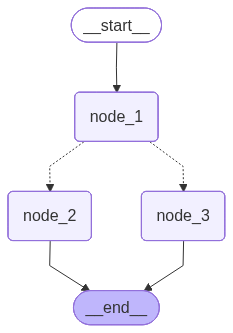

In [23]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node('node_1', node_1)
builder.add_node('node_2', node_2)
builder.add_node('node_3', node_3)

builder.add_edge(START, 'node_1')
builder.add_conditional_edges('node_1', decide_mood)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
graph.invoke({'graph_state': "hello, this is amar"})

---node 1---
---node 3---


{'graph_state': 'hello, this is amar I am  sad'}

In [54]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph
%pip install -qU langchain-groq


In [55]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were searching ocean Mammals right?", name="Model" )]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were searching ocean Mammals right?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [57]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")

In [58]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [59]:
result

AIMessage(content="Orcas, also known as killer whales, are a popular sight among marine life enthusiasts. In the US, one of the best places to see orcas is in the Pacific Northwest, specifically in the states of Washington and Alaska.\n\nSome of the top locations for orca watching in the US include:\n\n1. **San Juan Islands, Washington**: This archipelago is known for its resident orca population, and it's one of the best places in the world to see these magnificent creatures in their natural habitat. The San Juan Islands are home to the Southern Resident orcas, which are an endangered population of orcas that are protected by the US government.\n2. **Puget Sound, Washington**: Puget Sound is another great location for orca watching, with several tour operators offering guided tours to see these animals. The sound is home to a variety of marine life, including orcas, humpback whales, and gray whales.\n3. **Juneau, Alaska**: Juneau is a popular destination for orca watching, with many t

In [60]:
result.response_metadata

{'token_usage': {'completion_tokens': 459,
  'prompt_tokens': 94,
  'total_tokens': 553,
  'completion_time': 1.124505079,
  'completion_tokens_details': None,
  'prompt_time': 0.004924455,
  'prompt_tokens_details': None,
  'queue_time': 0.048756114,
  'total_time': 1.129429534},
 'model_name': 'llama-3.3-70b-versatile',
 'system_fingerprint': 'fp_dae98b5ecb',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

In [100]:
def multiply(a: int, b: int) -> int:
    """
    Multiply two numbers.
    
    You MUST provide both:
    - a (first integer)
    - b (second integer)
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [101]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3?", name = "Lance")])

In [65]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'np8ndw64g',
  'type': 'tool_call'}]

In [72]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages = list[AnyMessage]

In [73]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages = Annotated[list[AnyMessage], add_messages]

In [74]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    pass


In [76]:
initial_messages = [AIMessage(content=f"Hello, how can i assist you today?", name = "Model"),
                   HumanMessage(content="I'm looking for information in Marine Biology", name="Lance")]

new_message = AIMessage(content="Sure, I can help you with that. What are you perticularly interested in?", name="Model")

add_messages(initial_messages, new_message)

[AIMessage(content='Hello, how can i assist you today?', additional_kwargs={}, response_metadata={}, name='Model', id='d1810361-9931-47fc-a8d0-2bdd064b3dd4', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information in Marine Biology", additional_kwargs={}, response_metadata={}, name='Lance', id='f3f21fcb-2bef-4082-bc9e-84e83e7f1fcb'),
 AIMessage(content='Sure, I can help you with that. What are you perticularly interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='0c5b5135-e2b6-453c-a2ea-960d2808268a', tool_calls=[], invalid_tool_calls=[])]

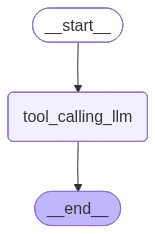

In [78]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

def tool_calling_llm(state: MessagesState):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(MessagesState)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_edge(START, 'tool_calling_llm')
builder.add_edge('tool_calling_llm', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
messages = graph.invoke({'messages': HumanMessage(content="Hello")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello. How can I assist you today?


In [81]:
messages = graph.invoke({'messages': HumanMessage(content="What is 2 muliplied by 3?")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 muliplied by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (4qfa81ne1)
 Call ID: 4qfa81ne1
  Args:
    a: 2
    b: 3


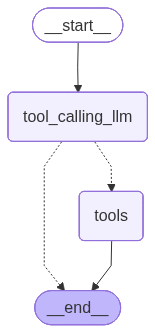

In [106]:
from langgraph.graph import START, END, StateGraph
from langgraph.graph import MessagesState
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state: MessagesState):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(MessagesState)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode([multiply]))
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm', tools_condition)
builder.add_edge('tool_calling_llm', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [107]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="What is 2 multiplied by 3? Use the multiply tool.")]
messages = graph.invoke({
    'messages': messages
})

for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 2 multiplied by 3? Use the multiply tool.
================================== Ai Message ==================================
Tool Calls:
  multiply (z5ymv350k)
 Call ID: z5ymv350k
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
